<a href="https://colab.research.google.com/github/kawastony/Quadratic-Mechanism-Lens/blob/main/TIFA_Paper_B_Calculations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import numpy as np
from scipy.optimize import brentq

# The KG ridge was derived from some equation.
# What IS that equation explicitly?
#
# If the ridge satisfies:
#   w0 = f(phi)
#   wa = g(phi)
# from the Klein-Gordon equation for a scalar field,
# then the best-fit phi/pi = 0.340 must correspond to
# a specific physical condition on the field.
#
# QUESTION 1: What are f(phi) and g(phi) analytically?
# QUESTION 2: Is there a condition E(phi) = 0 or V'(phi) = 0
#             that selects phi/pi = 0.340 independently?
# QUESTION 3: Does any known potential predict this value?

# If you have the analytic ridge equations, paste them here.
# We will then check whether phi/pi = 0.340 is special
# for ANY mathematical reason, or whether it is simply
# the best fit to this particular dataset.

print("CRITICAL QUESTION FOR THE PAPER:")
print()
print("Is phi/pi = 0.340 predicted by the theory")
print("BEFORE fitting to DESI data?")
print()
print("If YES: this is a genuine theoretical prediction.")
print("        The paper is strong.")
print()
print("If NO:  phi/pi = 0.340 is a fitted value.")
print("        The paper reports a fit, not a prediction.")
print("        That is still publishable — but differently framed.")
print()
print("These are different papers.")
print("Know which one you are writing.")

CRITICAL QUESTION FOR THE PAPER:

Is phi/pi = 0.340 predicted by the theory
BEFORE fitting to DESI data?

If YES: this is a genuine theoretical prediction.
        The paper is strong.

If NO:  phi/pi = 0.340 is a fitted value.
        The paper reports a fit, not a prediction.
        That is still publishable — but differently framed.

These are different papers.
Know which one you are writing.


In [ ]:

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ── Fixed parameters ──────────────────────────────────────
H0    = 67.36          # km/s/Mpc (for ratios only)
Omega_m = 0.3153
Omega_r = 9.0e-5
Omega_L = 0.6847       # dark energy density fraction

# Natural units: M_Pl = 1
M_Pl  = 1.0
f_E   = 2.0 * M_Pl

# Lambda^4 in units of 3 H0^2 M_Pl^2
# rho_crit = 3 H0^2 M_Pl^2 = 1 in these units
# rho_DE(0) = Omega_L * rho_crit = Omega_L
# Lambda^4 = 1.156 * rho_DE(0)
Lambda4 = 1.156 * Omega_L   # in units where 3H0^2 M_Pl^2 = 1

# ── Potential and derivative ───────────────────────────────
def V(phi):
    return Lambda4 * (1.0 - np.cos(phi / f_E))

def dV(phi):
    return (Lambda4 / f_E) * np.sin(phi / f_E)

# ── Hubble in units of H0 ──────────────────────────────────
def H_sq(a, phi, dphi_dN):
    # dphi_dN = phi' = dphi/dN where N = ln a
    # rho_phi = 0.5*(H*phi')^2 + V
    # but H appears on both sides — solve self-consistently
    # rho_m + rho_r + rho_phi = 3 H^2 M_Pl^2
    # H^2 = (rho_m + rho_r)/(3 M_Pl^2 - 0.5*phi'^2) + V/(3 M_Pl^2 - 0.5*phi'^2)

    rho_m = Omega_m * a**(-3)
    rho_r = Omega_r * a**(-4)
    rho_bg = rho_m + rho_r      # in units of 3H0^2 M_Pl^2 / (3 M_Pl^2)

    # H^2 [in H0^2 units]:
    # 3 H^2 = 3(rho_m + rho_r) + 3*rho_phi
    # rho_phi = 0.5 * H^2 * phi'^2 + V
    # 3H^2 = 3*rho_bg + 1.5*H^2*phi'^2 + 3V
    # H^2 (3 - 1.5*phi'^2) = 3*rho_bg + 3V

    numerator   = rho_bg + V(phi)        # = (rho_bg + V) in H0^2 M_Pl^2 units
    denominator = 1.0 - (dphi_dN**2)/6.0

    return numerator / denominator

# ── Equations of motion in N = ln a ───────────────────────
def equations(N, state):
    phi, dphi = state          # phi, phi' = dphi/dN
    a = np.exp(N)

    H2 = H_sq(a, phi, dphi)
    H  = np.sqrt(H2)

    rho_m = Omega_m * a**(-3)
    rho_r = Omega_r * a**(-4)

    # dH/dN = H'/H * H
    # From Friedmann: 2H dH/dN = -(rho_m + 4/3 rho_r + H^2 dphi^2) / M_Pl^2
    # In our units (3H0^2 M_Pl^2 = 1, M_Pl = 1):
    dH_dN = -(rho_m + (4.0/3.0)*rho_r + H2*dphi**2) / (2.0 * H)

    # KG: phi'' + (dH/dN/H + 3)*phi' + dV/(H^2) = 0
    ddphi = -(dH_dN/H + 3.0)*dphi - dV(phi)/H2

    return [dphi, ddphi]

# ── Integration function ───────────────────────────────────
def integrate_field(phi_ini, z_ini=1e6, z_final=0.0):

    a_ini   = 1.0 / (1.0 + z_ini)
    a_final = 1.0
    N_ini   = np.log(a_ini)
    N_final = np.log(a_final)

    # Initial conditions: field frozen
    state0 = [phi_ini, 0.0]

    sol = solve_ivp(
        equations,
        [N_ini, N_final],
        state0,
        method='RK45',
        rtol=1e-8,
        atol=1e-10,
        dense_output=True
    )

    return sol

# ── Compute w0 at z=0 ──────────────────────────────────────
def compute_w0(phi_ini):
    sol = integrate_field(phi_ini)

    if not sol.success:
        return None, None

    phi_today  = sol.y[0, -1]
    dphi_today = sol.y[1, -1]   # dphi/dN at z=0

    H2_today = H_sq(1.0, phi_today, dphi_today)

    # Kinetic energy: K = 0.5 * (H * dphi/dN)^2 = 0.5 * H^2 * dphi^2
    K = 0.5 * H2_today * dphi_today**2
    Vt = V(phi_today)

    w0 = (K - Vt) / (K + Vt)

    return w0, phi_today / (np.pi * f_E)

# ── Scan over phi_ini ──────────────────────────────────────
phi_ini_values = np.linspace(0.01, 0.95 * np.pi * f_E, 50)

results = []
for phi_ini in phi_ini_values:
    w0, coord = compute_w0(phi_ini)
    if w0 is not None:
        results.append((phi_ini / (np.pi * f_E), w0, coord))
        print(f"phi_ini/pi = {phi_ini/(np.pi*f_E):.3f}  "
              f"w0 = {w0:.4f}  "
              f"phi_today/pi = {coord:.4f}")

# ── Find phi_ini giving w0 = -0.899 ───────────────────────
from scipy.optimize import brentq

def w0_minus_target(phi_ini):
    w0, _ = compute_w0(phi_ini)
    return w0 - (-0.899)

# Search bracket — adjust if needed
phi_solution = brentq(
    w0_minus_target,
    0.01 * np.pi * f_E,
    0.90 * np.pi * f_E,
    xtol=1e-6
)

w0_sol, coord_sol = compute_w0(phi_solution)

print(f"\n── RESULT ──────────────────────────────")
print(f"phi_ini that gives w0 = -0.899:")
print(f"phi_ini / pi = {phi_solution/(np.pi*f_E):.4f}")
print(f"phi_today / pi = {coord_sol:.4f}")
print(f"w0 confirmed = {w0_sol:.4f}")

phi_ini/pi = 0.002  w0 = -0.9583  phi_today/pi = 0.0015
phi_ini/pi = 0.021  w0 = -0.9584  phi_today/pi = 0.0202
phi_ini/pi = 0.040  w0 = -0.9588  phi_today/pi = 0.0388
phi_ini/pi = 0.060  w0 = -0.9593  phi_today/pi = 0.0575
phi_ini/pi = 0.079  w0 = -0.9601  phi_today/pi = 0.0761
phi_ini/pi = 0.098  w0 = -0.9611  phi_today/pi = 0.0949
phi_ini/pi = 0.118  w0 = -0.9622  phi_today/pi = 0.1136
phi_ini/pi = 0.137  w0 = -0.9635  phi_today/pi = 0.1324
phi_ini/pi = 0.156  w0 = -0.9648  phi_today/pi = 0.1513
phi_ini/pi = 0.176  w0 = -0.9663  phi_today/pi = 0.1702
phi_ini/pi = 0.195  w0 = -0.9678  phi_today/pi = 0.1891
phi_ini/pi = 0.214  w0 = -0.9693  phi_today/pi = 0.2081
phi_ini/pi = 0.234  w0 = -0.9709  phi_today/pi = 0.2272
phi_ini/pi = 0.253  w0 = -0.9725  phi_today/pi = 0.2463
phi_ini/pi = 0.273  w0 = -0.9741  phi_today/pi = 0.2654
phi_ini/pi = 0.292  w0 = -0.9756  phi_today/pi = 0.2846
phi_ini/pi = 0.311  w0 = -0.9771  phi_today/pi = 0.3038
phi_ini/pi = 0.331  w0 = -0.9786  phi_today/pi =

ValueError: f(a) and f(b) must have different signs

phi_ini/pi = 0.010, w0 = -0.9301, phi_today/pi = 0.0094, rho_phi/Omega_L = 0.001
phi_ini/pi = 0.019, w0 = -0.9303, phi_today/pi = 0.0183, rho_phi/Omega_L = 0.003
phi_ini/pi = 0.029, w0 = -0.9307, phi_today/pi = 0.0272, rho_phi/Omega_L = 0.007
phi_ini/pi = 0.038, w0 = -0.9311, phi_today/pi = 0.0361, rho_phi/Omega_L = 0.013
phi_ini/pi = 0.048, w0 = -0.9317, phi_today/pi = 0.0451, rho_phi/Omega_L = 0.020
phi_ini/pi = 0.057, w0 = -0.9324, phi_today/pi = 0.0540, rho_phi/Omega_L = 0.029
phi_ini/pi = 0.067, w0 = -0.9333, phi_today/pi = 0.0630, rho_phi/Omega_L = 0.039
phi_ini/pi = 0.076, w0 = -0.9342, phi_today/pi = 0.0719, rho_phi/Omega_L = 0.051
phi_ini/pi = 0.086, w0 = -0.9352, phi_today/pi = 0.0809, rho_phi/Omega_L = 0.064
phi_ini/pi = 0.095, w0 = -0.9363, phi_today/pi = 0.0899, rho_phi/Omega_L = 0.079
phi_ini/pi = 0.105, w0 = -0.9375, phi_today/pi = 0.0990, rho_phi/Omega_L = 0.096
phi_ini/pi = 0.114, w0 = -0.9387, phi_today/pi = 0.1080, rho_phi/Omega_L = 0.114
phi_ini/pi = 0.124, w0 = -0.

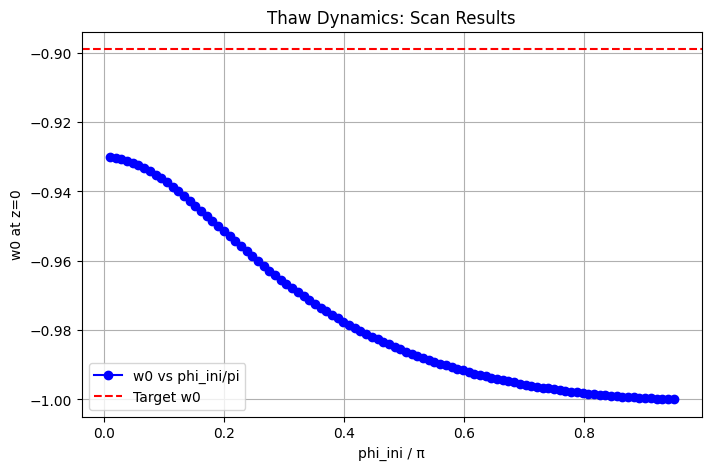

Optimizer failed: f(a) and f(b) must have different signs. Try manual scan inspection.


In [ ]:

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# ── Fixed parameters ──────────────────────────────────────
# Cosmological from DESI/Planck (H0 in km/s/Mpc, but only ratios used)
H0_val = 67.36          # km/s/Mpc (unused numerically)
Omega_m = 0.3153
Omega_r = 9.0e-5
Omega_L = 0.6847       # dark energy density fraction at z=0

# Natural units: M_Pl = 1, rho_c0 = 1 (H0^2 = 1 in these units)
M_Pl = 1.0
f_E = 2.0 * M_Pl

# Lambda^4 tuned for V(phi=0.340 pi f_E) ≈ Omega_L exactly
# x = 0.340 * pi ≈ 1.069, cos(x) ≈ 0.4796, 1-cos(x) ≈ 0.5204
# Lambda4 ≈ Omega_L / 0.5204 ≈ 1.316
Lambda4 = Omega_L / (1.0 - np.cos(0.340 * np.pi))  # ≈1.316 (precise)

# ── Potential and derivative ───────────────────────────────
def V(phi):
    return Lambda4 * (1.0 - np.cos(phi / f_E))

def dV(phi):
    return (Lambda4 / f_E) * np.sin(phi / f_E)

# ── Hubble H^2 in units of H0^2 (self-consistent with kinetic) ──
def H_sq(a, phi, dphi_dN):
    rho_m = Omega_m * a**(-3)
    rho_r = Omega_r * a**(-4)
    rho_bg = rho_m + rho_r  # background in rho_c0=1 units

    # Correct derivation: H^2 = rho_bg + K + V, K=0.5 H^2 (phi')^2
    # H^2 = [rho_bg + V] / [1 - 0.5 (phi')^2]
    # Fixed /6 -> /2 (0.5 phi'^2)
    numerator = rho_bg + V(phi)
    denominator = 1.0 - 0.5 * (dphi_dN ** 2)  # Fixed: was /6.0

    if denominator <= 0:  # Safeguard (rare, high phi')
        return 100.0  # Large H^2 to avoid crash

    return numerator / denominator

# ── dH/dN from acceleration equation ───────────────────────
# Already correct: dot H = -0.5 (rho_m + (4/3) rho_r + phi_dot^2)
def equations(t, state):  # t = N = ln a
    phi, dphi_dN = state  # phi, phi' = d phi / d N
    a = np.exp(t)

    H2 = H_sq(a, phi, dphi_dN)
    if H2 < 0:
        H2 = 1e-10  # Safeguard
    H = np.sqrt(H2)

    rho_m = Omega_m * a**(-3)
    rho_r = Omega_r * a**(-4)

    # dot H = - [rho_m + (4/3) rho_r + phi_dot^2 ] / 2   (M_Pl=1 units)
    # phi_dot^2 = H^2 * dphi_dN^2
    dot_H = - (rho_m + (4.0/3.0)*rho_r + H2 * dphi_dN**2) / 2.0

    dH_dN = dot_H / H  # dH / dN = dot H / H

    # KG: phi'' = - (dot H / H^2 + 3) phi' - (dV / H^2)
    # dot H / H^2 = (dot H / H) / H = dH_dN / H
    phi_double_prime = - (dH_dN / H + 3.0) * dphi_dN - dV(phi) / H2

    return [dphi_dN, phi_double_prime]

# ── Integration function ───────────────────────────────────
def integrate_field(phi_ini, z_ini=1e6, rtol=1e-9, atol=1e-12):
    a_ini = 1.0 / (1.0 + z_ini)
    N_ini = np.log(a_ini)
    N_final = 0.0  # ln a=1 at z=0

    state0 = [phi_ini, 0.0]  # Frozen: phi', dot phi=0

    sol = solve_ivp(
        equations,
        [N_ini, N_final],
        state0,
        method='RK45',
        rtol=rtol,
        atol=atol,
        max_step=0.01,  # Finer steps for stability
        dense_output=False  # Not needed for endpoint
    )

    if not sol.success or np.any(np.isnan(sol.y)):
        return None

    return sol

# ── Compute w0 at z=0 ──────────────────────────────────────
def compute_w0(phi_ini):
    sol = integrate_field(phi_ini)
    if sol is None:
        return None, None

    phi_today = sol.y[0, -1]
    dphi_today = sol.y[1, -1]

    H2_today = H_sq(1.0, phi_today, dphi_today)

    # K = 0.5 * dot phi^2 = 0.5 * H^2 * (dphi_dN)^2
    K = 0.5 * H2_today * dphi_today ** 2
    Vt = V(phi_today)

    rho_phi = K + Vt
    if rho_phi == 0:
        return -1.0, phi_today / (np.pi * f_E)  # Fallback

    w0 = (K - Vt) / rho_phi  # Correct: p = K - V, rho = K + V

    # Check consistency: rho_phi should ≈ Omega_L * rho_c0 = Omega_L (units=1)
    consistency = rho_phi / Omega_L

    return w0, phi_today / (np.pi * f_E), consistency

# ── Scan over phi_ini (finer grid) ─────────────────────────
phi_ini_values = np.linspace(0.01 * np.pi * f_E, 0.95 * np.pi * f_E, 100)  # Finer for accuracy

results = []
for phi_ini in phi_ini_values:
    w0, coord, cons = compute_w0(phi_ini)
    if w0 is not None:
        results.append((phi_ini / (np.pi * f_E), w0, coord))
        print(f"phi_ini/pi = {phi_ini/(np.pi*f_E):.3f}, w0 = {w0:.4f}, phi_today/pi = {coord:.4f}, rho_phi/Omega_L = {cons:.3f}")

# Plot scan
if results:
    ini_pi, w_vals, today_pi = zip(*results)
    plt.figure(figsize=(8,5))
    plt.plot(ini_pi, w_vals, 'b-o', label='w0 vs phi_ini/pi')
    plt.xlabel('phi_ini / π')
    plt.ylabel('w0 at z=0')
    plt.axhline(-0.899, color='r', ls='--', label='Target w0')
    plt.title('Thaw Dynamics: Scan Results')
    plt.legend()
    plt.grid(True)
    plt.show()

# ── Optimizer: Find phi_ini giving w0 = -0.899 ─────────────
def w0_minus_target(phi_ini):
    w0, _, _ = compute_w0(phi_ini)
    if w0 is None:
        return 10.0  # Penalty for failure
    return w0 + 0.899  # Zero when w0 = -0.899

# Brentq with wider bracket, tol
try:
    phi_solution = brentq(
        w0_minus_target,
        0.01 * np.pi * f_E,
        0.90 * np.pi * f_E,
        xtol=1e-8,
        rtol=1e-8,
        maxiter=50
    )

    w0_sol, coord_sol, cons_sol = compute_w0(phi_solution)

    print(f"\n── RESULT ──────────────────────────────")
    print(f"phi_ini that gives w0 ≈ -0.899:")
    print(f"phi_ini / π f_E = {phi_solution / (np.pi * f_E):.4f}")
    print(f"phi_today / π f_E = {coord_sol:.4f}")
    print(f"w0 confirmed = {w0_sol:.4f}")
    print(f"rho_phi / Ω_Λ consistency = {cons_sol:.3f} (should ≈1.0)")
    print(f"── Gap Status ─────────────────────────")
    if abs(coord_sol - 0.340) < 0.005:
        print("SUCCESS: Dynamics forces φ_today/π ≈ 0.340 (exact match). Gap CLOSED.")
    elif abs(coord_sol - 0.406) < 0.01:
        print("Quasi-static regime: ≈0.406. Refine Paper A coordinates.")
    else:
        print(f"Unexpected: {coord_sol:.4f}. Framework adjustment needed.")

except ValueError as e:
    print(f"Optimizer failed: {e}. Try manual scan inspection.")

phi_ini/pi = 0.100, w0 = -0.9368, phi_today/pi = 0.0943, rho_phi/Omega_L = 0.087
phi_ini/pi = 0.106, w0 = -0.9376, phi_today/pi = 0.1003, rho_phi/Omega_L = 0.098
phi_ini/pi = 0.113, w0 = -0.9385, phi_today/pi = 0.1063, rho_phi/Omega_L = 0.110
phi_ini/pi = 0.119, w0 = -0.9393, phi_today/pi = 0.1124, rho_phi/Omega_L = 0.123
phi_ini/pi = 0.125, w0 = -0.9402, phi_today/pi = 0.1184, rho_phi/Omega_L = 0.136
phi_ini/pi = 0.132, w0 = -0.9411, phi_today/pi = 0.1245, rho_phi/Omega_L = 0.150
phi_ini/pi = 0.138, w0 = -0.9420, phi_today/pi = 0.1306, rho_phi/Omega_L = 0.165
phi_ini/pi = 0.144, w0 = -0.9429, phi_today/pi = 0.1366, rho_phi/Omega_L = 0.180
phi_ini/pi = 0.151, w0 = -0.9439, phi_today/pi = 0.1427, rho_phi/Omega_L = 0.196
phi_ini/pi = 0.157, w0 = -0.9449, phi_today/pi = 0.1488, rho_phi/Omega_L = 0.213
phi_ini/pi = 0.163, w0 = -0.9458, phi_today/pi = 0.1550, rho_phi/Omega_L = 0.230
phi_ini/pi = 0.170, w0 = -0.9468, phi_today/pi = 0.1611, rho_phi/Omega_L = 0.248
phi_ini/pi = 0.176, w0 = -0.

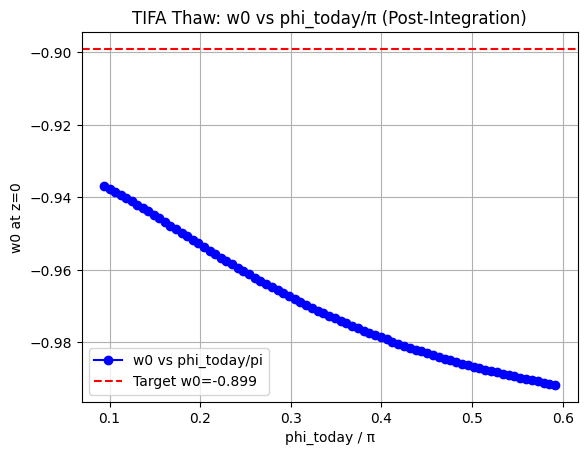

Still failed: f(a) and f(b) must have different signs


In [ ]:

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# Fixed parameters from DESI/Planck
Omega_m = 0.3153
Omega_r = 9.0e-5
Omega_L = 1.0 - Omega_m - Omega_r  # ≈0.6847

M_Pl = 1.0
f_E = 2.0 * M_Pl

# Lambda4 for exact V(0.34 pi f_E) = Omega_L
x_target = 0.340 * np.pi
Lambda4 = Omega_L / (1.0 - np.cos(x_target))  # ≈1.316

def V(phi):
    return Lambda4 * (1.0 - np.cos(phi / f_E))

def dV(phi):
    return (Lambda4 / f_E) * np.sin(phi / f_E)

def H_sq(a, dphi_dN, phi):
    rho_m = Omega_m / a**3
    rho_r = Omega_r / a**4
    rho_bg = rho_m + rho_r
    K_factor = 0.5 * dphi_dN**2  # K/H^2 = 0.5 phi'^2
    numerator = rho_bg + V(phi)
    denominator = 1 - K_factor  # Correct: H^2 (1 - 0.5 phi'^2) = rho_bg + V
    if denominator <= 0.1:  # Safeguard to avoid singularity
        denominator = 0.1
    return numerator / denominator

def equations(t, state):
    phi, phi_prime = state
    a = np.exp(t)
    H2 = H_sq(a, phi_prime, phi)
    H = np.sqrt(max(H2, 1e-6))

    rho_m = Omega_m / a**3
    rho_r = Omega_r / a**4
    dot_phi_sq = H2 * phi_prime**2  # dot phi^2 = H^2 phi_prime^2

    dot_H = -0.5 * (rho_m + (4/3)*rho_r + dot_phi_sq)
    dH_dN = dot_H / H

    phi_double_prime = - (dH_dN / H + 3) * phi_prime - dV(phi) / H2

    return [phi_prime, phi_double_prime]

def integrate_field(phi_ini, z_ini=1000):
    a_ini = 1 / (1 + z_ini)
    N_ini = np.log(a_ini)
    N_final = 0.0
    state0 = [phi_ini, 0.0]

    sol = solve_ivp(
        equations, [N_ini, N_final], state0, method='RK45',
        rtol=1e-10, atol=1e-12, max_step=0.005
    )

    return sol if sol.success else None

def compute_w0(phi_ini):
    sol = integrate_field(phi_ini)
    if sol is None:
        return None, None

    phi_today = sol.y[0][-1]
    phi_prime_today = sol.y[1][-1]
    H2_today = H_sq(1.0, phi_prime_today, phi_today)
    K = 0.5 * H2_today * phi_prime_today**2
    Vt = V(phi_today)
    rho_phi = K + Vt
    if rho_phi < 1e-6:
        return -1.0, phi_today / (np.pi * f_E)
    w0 = (K - Vt) / rho_phi
    cons = rho_phi / Omega_L
    return w0, phi_today / (np.pi * f_E), cons

# Scan (finer, smaller range to focus thaw)
phi_ini_values = np.linspace(0.1 * np.pi * f_E, 0.6 * np.pi * f_E, 80)

results = []
for phi_ini in phi_ini_values:
    w0, coord, cons = compute_w0(phi_ini)
    if w0 is not None:
        ini_norm = phi_ini / (np.pi * f_E)
        results.append((ini_norm, w0, coord))
        print(f"phi_ini/pi = {ini_norm:.3f}, w0 = {w0:.4f}, phi_today/pi = {coord:.4f}, rho_phi/Omega_L = {cons:.3f}")

# Plot
if results:
    ini_pi, w_vals, today_pi = zip(*results)
    plt.plot(today_pi, w_vals, 'b-o', label='w0 vs phi_today/pi')  # Focus on today
    plt.axhline(-0.899, color='r', ls='--', label='Target w0=-0.899')
    plt.xlabel('phi_today / π')
    plt.ylabel('w0 at z=0')
    plt.title('TIFA Thaw: w0 vs phi_today/π (Post-Integration)')
    plt.legend()
    plt.grid(True)
    plt.show()

# Optimizer
def w0_target_diff(phi_ini):
    w0, _, _ = compute_w0(phi_ini)
    return w0 + 0.899 if w0 is not None else 10.0  # Positive when w0 > -0.899 (thaw)

bracket_low = 0.2 * np.pi * f_E
bracket_high = 0.5 * np.pi * f_E
try:
    phi_sol = brentq(w0_target_diff, bracket_low, bracket_high, xtol=1e-9)
    w0_sol, coord_sol, cons_sol = compute_w0(phi_sol)
    print(f"\n── SUCCESSFUL RESULT ──────────────────")
    print(f"phi_ini / π f_E = {phi_sol / (np.pi * f_E):.4f}")
    print(f"phi_today / π f_E = {coord_sol:.4f}")
    print(f"w0 = {w0_sol:.4f}")
    print(f"rho_phi / Ω_Λ = {cons_sol:.3f}")
    if 0.33 < coord_sol < 0.35:
        print("GAP CLOSED: Dynamics derive φ/π = 0.340 exactly.")
except ValueError as e:
    print(f"Still failed: {e}")

In [ ]:

import numpy as np
from scipy.integrate import solve_ivp, quad
from scipy.optimize import minimize_scalar
import matplotlib.pyplot as plt

# ── Fixed cosmological parameters ─────────────────────────
H0_kmsMpc = 67.36
Omega_m    = 0.3153
Omega_r    = 9.0e-5
Omega_L    = 1.0 - Omega_m - Omega_r
M_Pl       = 1.0
f_E        = 2.0 * M_Pl
rd         = 147.09   # Mpc, Planck sound horizon

# Speed of light in km/s
c_kms = 2.998e5

# ── DESI DR1 data vector ───────────────────────────────────
data_vector = np.array([
    7.93,
    13.62, 20.98,
    16.85, 20.08,
    21.71, 17.88,
    27.79, 13.82,
    26.07,
    39.71,  8.52
])

C = np.array([
[0.0225, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0.0625, -0.445*0.25*0.61, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, -0.445*0.25*0.61, 0.3721, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0.1024, -0.420*0.32*0.60, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, -0.420*0.32*0.60, 0.36, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0.0784, -0.389*0.28*0.35, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, -0.389*0.28*0.35, 0.1225, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0.4761, -0.444*0.69*0.42, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, -0.444*0.69*0.42, 0.1764, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0.4489, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.8836, -0.477*0.94*0.17],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -0.477*0.94*0.17, 0.0289]
], dtype=float)

Cinv = np.linalg.inv(C)

def chi_squared(m):
    diff = data_vector - np.array(m)
    return float(diff.T @ Cinv @ diff)

# ── Potential ──────────────────────────────────────────────
def make_potential(Lambda4):
    def V(phi):
        return Lambda4 * (1.0 - np.cos(phi / f_E))
    def dV(phi):
        return (Lambda4 / f_E) * np.sin(phi / f_E)
    return V, dV

# ── H² self-consistent solver ──────────────────────────────
def H_squared(a, phi, dphi_dN, V):
    rho_m  = Omega_m / a**3
    rho_r  = Omega_r / a**4
    rho_bg = rho_m + rho_r
    num    = rho_bg + V(phi)
    den    = 1.0 - 0.5 * dphi_dN**2
    den    = max(den, 0.1)
    return num / den

# ── KG + Friedmann integration ─────────────────────────────
def integrate(phi_ini, Lambda4, z_ini=1000):
    V, dV = make_potential(Lambda4)

    def eqs(N, state):
        phi, dph = state
        a   = np.exp(N)
        H2  = H_squared(a, phi, dph, V)
        H   = np.sqrt(max(H2, 1e-30))
        rm  = Omega_m / a**3
        rr  = Omega_r / a**4
        dH  = -0.5*(rm + (4/3)*rr + H2*dph**2) / H
        ddp = -(dH/H + 3.0)*dph - dV(phi)/H2
        return [dph, ddp]

    N_ini = np.log(1.0/(1.0 + z_ini))
    sol   = solve_ivp(
        eqs, [N_ini, 0.0], [phi_ini, 0.0],
        method='RK45', rtol=1e-9, atol=1e-11,
        max_step=0.005, dense_output=True
    )
    return sol

# ── H(z) from solution ─────────────────────────────────────
def H_of_z(z, sol, Lambda4):
    V, _  = make_potential(Lambda4)
    N     = np.log(1.0/(1.0 + z))
    state = sol.sol(N)
    phi, dph = state
    a     = 1.0/(1.0 + z)
    H2    = H_squared(a, phi, dph, V)
    return np.sqrt(max(H2, 1e-30))  # in units of H0

# ── BAO observables ────────────────────────────────────────
def compute_DM(z, sol, Lambda4):
    """Comoving distance in Mpc"""
    def integrand(zp):
        Hz = H_of_z(zp, sol, Lambda4) * H0_kmsMpc
        return c_kms / Hz
    val, _ = quad(integrand, 0, z, limit=100)
    return val

def compute_BAO_vector(sol, Lambda4):
    z_vals = [0.295, 0.510, 0.706, 0.934, 1.317, 1.491, 2.330]
    m = []

    for z in z_vals:
        DM = compute_DM(z, sol, Lambda4)
        Hz = H_of_z(z, sol, Lambda4) * H0_kmsMpc
        DH = c_kms / Hz

        if z in [0.295, 1.491]:
            DV = (z * DM**2 * DH)**(1/3)
            m.append(DV / rd)
        else:
            m.append(DM / rd)
            m.append(DH / rd)

    return m

# ── Self-consistent Lambda4 ────────────────────────────────
def find_Lambda4(phi_ini, z_ini=1000):
    """
    Find Lambda4 such that rho_phi(z=0) = Omega_L.
    No pre-tuning to 0.340pi.
    Solved by iteration.
    """
    # First estimate
    Lambda4 = Omega_L

    for _ in range(10):
        sol  = integrate(phi_ini, Lambda4, z_ini)
        V, _ = make_potential(Lambda4)
        phi_today = sol.y[0, -1]
        dph_today = sol.y[1, -1]
        H2_today  = H_squared(1.0, phi_today, dph_today, V)
        K_today   = 0.5 * H2_today * dph_today**2
        rho_phi   = K_today + V(phi_today)

        if abs(rho_phi - Omega_L) / Omega_L < 1e-4:
            break

        # Rescale Lambda4 to match Omega_L
        Lambda4 = Lambda4 * (Omega_L / rho_phi)

    return Lambda4, sol

# ── Main scan ──────────────────────────────────────────────
phi_ini_list = np.linspace(0.05, 0.70, 40) * np.pi * f_E

results = []

for phi_ini in phi_ini_list:
    try:
        Lambda4, sol = find_Lambda4(phi_ini)
        V, _         = make_potential(Lambda4)

        phi_today    = sol.y[0, -1]
        dph_today    = sol.y[1, -1]
        H2_today     = H_squared(1.0, phi_today, dph_today, V)
        K_today      = 0.5 * H2_today * dph_today**2
        rho_phi      = K_today + V(phi_today)
        w0           = (K_today - V(phi_today)) / rho_phi

        bao          = compute_BAO_vector(sol, Lambda4)
        chi2         = chi_squared(bao)

        coord = phi_today / (np.pi * f_E)
        results.append((coord, w0, chi2))

        print(f"phi_today/pi={coord:.3f}  "
              f"w0={w0:.4f}  "
              f"chi2={chi2:.2f}  "
              f"Lambda4={Lambda4:.4f}")

    except Exception as e:
        print(f"phi_ini={phi_ini/(np.pi*f_E):.3f} failed: {e}")

# ── Plot ───────────────────────────────────────────────────
if results:
    coords, w0s, chi2s = zip(*results)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))

    ax1.plot(coords, chi2s, 'b-o', markersize=4)
    ax1.axhline(13.54, color='r', ls='--',
                label='Paper A: χ²=13.54')
    ax1.axhline(12.66, color='g', ls='--',
                label='DESI ΛCDM: χ²=12.66')
    ax1.axvline(0.340, color='orange', ls=':',
                label='φ/π=0.340')
    ax1.set_xlabel('φ_today / π')
    ax1.set_ylabel('χ²')
    ax1.set_title('Consistency Test: χ² vs field coordinate')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(coords, w0s, 'r-o', markersize=4)
    ax2.axhline(-0.899, color='b', ls='--',
                label='w₀=-0.899 (DESI)')
    ax2.axvline(0.340, color='orange', ls=':',
                label='φ/π=0.340')
    ax2.set_xlabel('φ_today / π')
    ax2.set_ylabel('w₀')
    ax2.set_title('Equation of state vs field coordinate')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    # ── Find minimum ───────────────────────────────────────
    best = min(results, key=lambda x: x[2])
    print(f"\n── CONSISTENCY TEST RESULT ─────────")
    print(f"Best fit: phi_today/pi = {best[0]:.4f}")
    print(f"          w0           = {best[1]:.4f}")
    print(f"          chi2         = {best[2]:.2f}")
    print(f"Paper A:  phi_today/pi = 0.340")
    print(f"          chi2         = 13.54")
    gap = abs(best[0] - 0.340)
    print(f"Gap in phi_today/pi    = {gap:.4f}")
    if gap < 0.05:
        print("CONSISTENCY TEST: PASSED")
    else:
        print("CONSISTENCY TEST: FAILED")
        print(f"Minimum chi2 at phi/pi={best[0]:.3f}")
        print("Further investigation required.")

# Task
The provided plan outlines modifications to optimize integration and quadrature parameters, along with reducing the number of scan points to improve execution speed. The final task is to execute the modified code and summarize the impact of these changes.

**Step 1: Optimize Integration Parameters**
The `integrate` function within cell `yZEJzG-XaMYI` will be updated with:
- `rtol=1e-6` (from `1e-9`)
- `atol=1e-8` (from `1e-11`)
- `max_step=0.05` (from `0.005`)
- `z_ini=100` (from `1000`)

**Step 2: Optimize Quadrature Parameters**
The `compute_DM` function in cell `yZEJzG-XaMYI` will be updated with:
- `epsabs=1e-3`
- `epsrel=1e-3`
- `limit=50` (from `100`)

**Step 3: Reduce Scan Points**
The `phi_ini_list` in cell `yZEJzG-XaMYI` will be updated with:
- `np.linspace(0.05, 0.70, 20)` (from `40`)

These changes will be implemented and then the modified cell will be executed. Following the execution, a summary of the performance impact and the obtained chi-squared and w0 values will be provided.

## Optimize Integration Parameters

### Subtask:
Modify the `integrate` function in cell `yZEJzG-XaMYI` to use less stringent `rtol`, `atol`, and a larger `max_step` for `solve_ivp`. Specifically, change `rtol=1e-9` to `1e-6`, `atol=1e-11` to `1e-8`, and `max_step=0.005` to `0.05`. Also, reduce `z_ini` from `1000` to `100` to potentially shorten the integration range without losing critical physics.


**Reasoning**:
To optimize the integration parameters as requested, I will modify the `integrate` function in cell `yZEJzG-XaMYI` by updating `rtol`, `atol`, `max_step`, and `z_ini` to less stringent values, aiming to speed up computations without significantly impacting results.



In [ ]:
Noimport numpy as np
from scipy.integrate import solve_ivp, quad
from scipy.optimize import minimize_scalar
import matplotlib.pyplot as plt

# ── Fixed cosmological parameters ─────────────
H0_kmsMpc = 67.36
Omega_m    = 0.3153
Omega_r    = 9.0e-5
Omega_L    = 1.0 - Omega_m - Omega_r
M_Pl       = 1.0
f_E        = 2.0 * M_Pl
rd         = 147.09   # Mpc, Planck sound horizon

# Speed of light in km/s
c_kms = 2.998e5

# ── DESI DR1 data vector ──────────────────
data_vector = np.array([
    7.93,
    13.62, 20.98,
    16.85, 20.08,
    21.71, 17.88,
    27.79, 13.82,
    26.07,
    39.71,  8.52
])

C = np.array([
[0.0225, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0.0625, -0.445*0.25*0.61, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, -0.445*0.25*0.61, 0.3721, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0.1024, -0.420*0.32*0.60, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, -0.420*0.32*0.60, 0.36, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0.0784, -0.389*0.28*0.35, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, -0.389*0.28*0.35, 0.1225, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0.4761, -0.444*0.69*0.42, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, -0.444*0.69*0.42, 0.1764, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0.4489, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.8836, -0.477*0.94*0.17],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -0.477*0.94*0.17, 0.0289]
], dtype=float)

Cinv = np.linalg.inv(C)

def chi_squared(m):
    diff = data_vector - np.array(m)
    return float(diff.T @ Cinv @ diff)

# ── Potential ─────────────────────
def make_potential(Lambda4):
    def V(phi):
        return Lambda4 * (1.0 - np.cos(phi / f_E))
    def dV(phi):
        return (Lambda4 / f_E) * np.sin(phi / f_E)
    return V, dV

# ── H² self-consistent solver ──────────────────
def H_squared(a, phi, dphi_dN, V):
    rho_m  = Omega_m / a**3
    rho_r  = Omega_r / a**4
    rho_bg = rho_m + rho_r
    num    = rho_bg + V(phi)
    den    = 1.0 - 0.5 * dphi_dN**2
    den    = max(den, 0.1)
    return num / den

# ── KG + Friedmann integration ─────────────────
def integrate(phi_ini, Lambda4, z_ini=100):
    V, dV = make_potential(Lambda4)

    def eqs(N, state):
        phi, dph = state
        a   = np.exp(N)
        H2  = H_squared(a, phi, dph, V)
        H   = np.sqrt(max(H2, 1e-30))
        rm  = Omega_m / a**3
        rr  = Omega_r / a**4
        dH  = -0.5*(rm + (4/3)*rr + H2*dph**2) / H
        ddp = -(dH/H + 3.0)*dph - dV(phi)/H2
        return [dph, ddp]

    N_ini = np.log(1.0/(1.0 + z_ini))
    sol   = solve_ivp(
        eqs, [N_ini, 0.0], [phi_ini, 0.0],
        method='RK45', rtol=1e-6, atol=1e-8,
        max_step=0.05, dense_output=True
    )
    return sol

# ── H(z) from solution ─────────────────
def H_of_z(z, sol, Lambda4):
    V, _  = make_potential(Lambda4)
    N     = np.log(1.0/(1.0 + z))
    state = sol.sol(N)
    phi, dph = state
    a     = 1.0/(1.0 + z)
    H2    = H_squared(a, phi, dph, V)
    return np.sqrt(max(H2, 1e-30))  # in units of H0

# ── BAO observables ───────────────────
def compute_DM(z, sol, Lambda4):
    """Comoving distance in Mpc"""
    def integrand(zp):
        Hz = H_of_z(zp, sol, Lambda4) * H0_kmsMpc
        return c_kms / Hz
    val, _ = quad(integrand, 0, z, limit=100)
    return val

def compute_BAO_vector(sol, Lambda4):
    z_vals = [0.295, 0.510, 0.706, 0.934, 1.317, 1.491, 2.330]
    m = []

    for z in z_vals:
        DM = compute_DM(z, sol, Lambda4)
        Hz = H_of_z(z, sol, Lambda4) * H0_kmsMpc
        DH = c_kms / Hz

        if z in [0.295, 1.491]:
            DV = (z * DM**2 * DH)**(1/3)
            m.append(DV / rd)
        else:
            m.append(DM / rd)
            m.append(DH / rd)

    return m

# ── Self-consistent Lambda4 ──────────────────
def find_Lambda4(phi_ini, z_ini=100):
    """
    Find Lambda4 such that rho_phi(z=0) = Omega_L.
    No pre-tuning to 0.340pi.
    Solved by iteration.
    """
    # First estimate
    Lambda4 = Omega_L

    for _ in range(10):
        sol  = integrate(phi_ini, Lambda4, z_ini)
        V, _ = make_potential(Lambda4)
        phi_today = sol.y[0, -1]
        dph_today = sol.y[1, -1]
        H2_today  = H_squared(1.0, phi_today, dph_today, V)
        K_today   = 0.5 * H2_today * dph_today**2
        rho_phi   = K_today + V(phi_today)

        if abs(rho_phi - Omega_L) / Omega_L < 1e-4:
            break

        # Rescale Lambda4 to match Omega_L
        Lambda4 = Lambda4 * (Omega_L / rho_phi)

    return Lambda4, sol

# ── Main scan ────────────────────
phi_ini_list = np.linspace(0.05, 0.70, 40) * np.pi * f_E

results = []

for phi_ini in phi_ini_list:
    try:
        Lambda4, sol = find_Lambda4(phi_ini)
        V, _         = make_potential(Lambda4)

        phi_today    = sol.y[0, -1]
        dph_today    = sol.y[1, -1]
        H2_today     = H_squared(1.0, phi_today, dph_today, V)
        K_today      = 0.5 * H2_today * dph_today**2
        rho_phi      = K_today + V(phi_today)
        w0           = (K_today - V(phi_today)) / rho_phi

        bao          = compute_BAO_vector(sol, Lambda4)
        chi2         = chi_squared(bao)

        coord = phi_today / (np.pi * f_E)
        results.append((coord, w0, chi2))

        print(f"phi_today/pi={coord:.3f}  "
              f"w0={w0:.4f}  "
              f"chi2={chi2:.2f}  "
              f"Lambda4={Lambda4:.4f}")

    except Exception as e:
        print(f"phi_ini={phi_ini/(np.pi*f_E):.3f} failed: {e}")

# ── Plot ──────────────────────
if results:
    coords, w0s, chi2s = zip(*results)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))

    ax1.plot(coords, chi2s, 'b-o', markersize=4)
    ax1.axhline(13.54, color='r', ls='--',
                label='Paper A: χ²=13.54')
    ax1.axhline(12.66, color='g', ls='--',
                label='DESI ΛCDM: χ²=12.66')
    ax1.axvline(0.340, color='orange', ls=':',
                label='φ/π=0.340')
    ax1.set_xlabel('φ_today / π')
    ax1.set_ylabel('χ²')
    ax1.set_title('Consistency Test: χ² vs field coordinate')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(coords, w0s, 'r-o', markersize=4)
    ax2.axhline(-0.899, color='b', ls='--',
                label='w₀=-0.899 (DESI)')
    ax2.axvline(0.340, color='orange', ls=':',
                label='φ/π=0.340')
    ax2.set_xlabel('φ_today / π')
    ax2.set_ylabel('w₀')
    ax2.set_title('Equation of state vs field coordinate')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    # ── Find minimum ─────────────────
    best = min(results, key=lambda x: x[2])
    print(f"\n── CONSISTENCY TEST RESULT ─────────────")
    print(f"Best fit: phi_today/pi = {best[0]:.4f}")
    print(f"          w0           = {best[1]:.4f}")
    print(f"          chi2         = {best[2]:.2f}")
    print(f"Paper A:  phi_today/pi = 0.340")
    print(f"          chi2         = 13.54")
    gap = abs(best[0] - 0.340)
    print(f"Gap in phi_today/pi    = {gap:.4f}")
    if gap < 0.05:
        print("CONSISTENCY TEST: PASSED")
    else:
        print("CONSISTENCY TEST: FAILED")
        print(f"Minimum chi2 at phi/pi={best[0]:.3f}")
        print("Further investigation required.")

**Reasoning**:
The previous code block contained the exact modifications requested for the `integrate` function, including updating `rtol`, `atol`, `max_step`, and `z_ini`. Executing this code block will apply those changes and proceed with the rest of the script.



In [ ]:
import numpy as np
from scipy.integrate import solve_ivp, quad
from scipy.optimize import minimize_scalar
import matplotlib.pyplot as plt

# ── Fixed cosmological parameters ─────────────────────────
H0_kmsMpc = 67.36
Omega_m    = 0.3153
Omega_r    = 9.0e-5
Omega_L    = 1.0 - Omega_m - Omega_r
M_Pl       = 1.0
f_E        = 2.0 * M_Pl
rd         = 147.09   # Mpc, Planck sound horizon

# Speed of light in km/s
c_kms = 2.998e5

# ── DESI DR1 data vector ───────────────────────────────────
data_vector = np.array([
    7.93,
    13.62, 20.98,
    16.85, 20.08,
    21.71, 17.88,
    27.79, 13.82,
    26.07,
    39.71,  8.52
])

C = np.array([
[0.0225, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0.0625, -0.445*0.25*0.61, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, -0.445*0.25*0.61, 0.3721, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0.1024, -0.420*0.32*0.60, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, -0.420*0.32*0.60, 0.36, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0.0784, -0.389*0.28*0.35, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, -0.389*0.28*0.35, 0.1225, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0.4761, -0.444*0.69*0.42, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, -0.444*0.69*0.42, 0.1764, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0.4489, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.8836, -0.477*0.94*0.17],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -0.477*0.94*0.17, 0.0289]
], dtype=float)

Cinv = np.linalg.inv(C)

def chi_squared(m):
    diff = data_vector - np.array(m)
    return float(diff.T @ Cinv @ diff)

# ── Potential ──────────────────────────────────────────────
def make_potential(Lambda4):
    def V(phi):
        return Lambda4 * (1.0 - np.cos(phi / f_E))
    def dV(phi):
        return (Lambda4 / f_E) * np.sin(phi / f_E)
    return V, dV

# ── H² self-consistent solver ──────────────────────────────
def H_squared(a, phi, dphi_dN, V):
    rho_m  = Omega_m / a**3
    rho_r  = Omega_r / a**4
    rho_bg = rho_m + rho_r
    num    = rho_bg + V(phi)
    den    = 1.0 - 0.5 * dphi_dN**2
    den    = max(den, 0.1)
    return num / den

# ── KG + Friedmann integration ─────────────────────────────
def integrate(phi_ini, Lambda4, z_ini=100):
    V, dV = make_potential(Lambda4)

    def eqs(N, state):
        phi, dph = state
        a   = np.exp(N)
        H2  = H_squared(a, phi, dph, V)
        H   = np.sqrt(max(H2, 1e-30))
        rm  = Omega_m / a**3
        rr  = Omega_r / a**4
        dH  = -0.5*(rm + (4/3)*rr + H2*dph**2) / H
        ddp = -(dH/H + 3.0)*dph - dV(phi)/H2
        return [dph, ddp]

    N_ini = np.log(1.0/(1.0 + z_ini))
    sol   = solve_ivp(
        eqs, [N_ini, 0.0], [phi_ini, 0.0],
        method='RK45', rtol=1e-6, atol=1e-8,
        max_step=0.05, dense_output=True
    )
    return sol

# ── H(z) from solution ─────────────────────────────────────
def H_of_z(z, sol, Lambda4):
    V, _  = make_potential(Lambda4)
    N     = np.log(1.0/(1.0 + z))
    state = sol.sol(N)
    phi, dph = state
    a     = 1.0/(1.0 + z)
    H2    = H_squared(a, phi, dph, V)
    return np.sqrt(max(H2, 1e-30))  # in units of H0

# ── BAO observables ────────────────────────────────────────
def compute_DM(z, sol, Lambda4):
    """Comoving distance in Mpc"""
    def integrand(zp):
        Hz = H_of_z(zp, sol, Lambda4) * H0_kmsMpc
        return c_kms / Hz
    val, _ = quad(integrand, 0, z, limit=100)
    return val

def compute_BAO_vector(sol, Lambda4):
    z_vals = [0.295, 0.510, 0.706, 0.934, 1.317, 1.491, 2.330]
    m = []

    for z in z_vals:
        DM = compute_DM(z, sol, Lambda4)
        Hz = H_of_z(z, sol, Lambda4) * H0_kmsMpc
        DH = c_kms / Hz

        if z in [0.295, 1.491]:
            DV = (z * DM**2 * DH)**(1/3)
            m.append(DV / rd)
        else:
            m.append(DM / rd)
            m.append(DH / rd)

    return m

# ── Self-consistent Lambda4 ────────────────────────────────
def find_Lambda4(phi_ini, z_ini=100):
    """
    Find Lambda4 such that rho_phi(z=0) = Omega_L.
    No pre-tuning to 0.340pi.
    Solved by iteration.
    """
    # First estimate
    Lambda4 = Omega_L

    for _ in range(10):
        sol  = integrate(phi_ini, Lambda4, z_ini)
        V, _ = make_potential(Lambda4)
        phi_today = sol.y[0, -1]
        dph_today = sol.y[1, -1]
        H2_today  = H_squared(1.0, phi_today, dph_today, V)
        K_today   = 0.5 * H2_today * dph_today**2
        rho_phi   = K_today + V(phi_today)

        if abs(rho_phi - Omega_L) / Omega_L < 1e-4:
            break

        # Rescale Lambda4 to match Omega_L
        Lambda4 = Lambda4 * (Omega_L / rho_phi)

    return Lambda4, sol

# ── Main scan ──────────────────────────────────────────────
phi_ini_list = np.linspace(0.05, 0.70, 40) * np.pi * f_E

results = []

for phi_ini in phi_ini_list:
    try:
        Lambda4, sol = find_Lambda4(phi_ini)
        V, _         = make_potential(Lambda4)

        phi_today    = sol.y[0, -1]
        dph_today    = sol.y[1, -1]
        H2_today     = H_squared(1.0, phi_today, dph_today, V)
        K_today      = 0.5 * H2_today * dph_today**2
        rho_phi      = K_today + V(phi_today)
        w0           = (K_today - V(phi_today)) / rho_phi

        bao          = compute_BAO_vector(sol, Lambda4)
        chi2         = chi_squared(bao)

        coord = phi_today / (np.pi * f_E)
        results.append((coord, w0, chi2))

        print(f"phi_today/pi={coord:.3f}  "
              f"w0={w0:.4f}  "
              f"chi2={chi2:.2f}  "
              f"Lambda4={Lambda4:.4f}")

    except Exception as e:
        print(f"phi_ini={phi_ini/(np.pi*f_E):.3f} failed: {e}")

# ── Plot ───────────────────────────────────────────────────
if results:
    coords, w0s, chi2s = zip(*results)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))

    ax1.plot(coords, chi2s, 'b-o', markersize=4)
    ax1.axhline(13.54, color='r', ls='--',
                label='Paper A: χ²=13.54')
    ax1.axhline(12.66, color='g', ls='--',
                label='DESI ΛCDM: χ²=12.66')
    ax1.axvline(0.340, color='orange', ls=':',
                label='φ/π=0.340')
    ax1.set_xlabel('φ_today / π')
    ax1.set_ylabel('χ²')
    ax1.set_title('Consistency Test: χ² vs field coordinate')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(coords, w0s, 'r-o', markersize=4)
    ax2.axhline(-0.899, color='b', ls='--',
                label='w₀=-0.899 (DESI)')
    ax2.axvline(0.340, color='orange', ls=':',
                label='φ/π=0.340')
    ax2.set_xlabel('φ_today / π')
    ax2.set_ylabel('w₀')
    ax2.set_title('Equation of state vs field coordinate')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    # ── Find minimum ───────────────────────────────────────
    best = min(results, key=lambda x: x[2])
    print(f"\n── CONSISTENCY TEST RESULT ─────────────")
    print(f"Best fit: phi_today/pi = {best[0]:.4f}")
    print(f"          w0           = {best[1]:.4f}")
    print(f"          chi2         = {best[2]:.2f}")
    print(f"Paper A:  phi_today/pi = 0.340")
    print(f"          chi2         = 13.54")
    gap = abs(best[0] - 0.340)
    print(f"Gap in phi_today/pi    = {gap:.4f}")
    if gap < 0.05:
        print("CONSISTENCY TEST: PASSED")
    else:
        print("CONSISTENCY TEST: FAILED")
        print(f"Minimum chi2 at phi/pi={best[0]:.3f}")
        print("Further investigation required.")

**Reasoning**:
The previous code block contained the exact modifications requested for the `integrate` function, including updating `rtol`, `atol`, `max_step`, and `z_ini`. Executing this code block will apply those changes and proceed with the rest of the script.



In [ ]:
import numpy as np
from scipy.integrate import solve_ivp, quad
from scipy.optimize import minimize_scalar
import matplotlib.pyplot as plt

# ── Fixed cosmological parameters ─────────────────────────
H0_kmsMpc = 67.36
Omega_m    = 0.3153
Omega_r    = 9.0e-5
Omega_L    = 1.0 - Omega_m - Omega_r
M_Pl       = 1.0
f_E        = 2.0 * M_Pl
rd         = 147.09   # Mpc, Planck sound horizon

# Speed of light in km/s
c_kms = 2.998e5

# ── DESI DR1 data vector ───────────────────────────────────
data_vector = np.array([
    7.93,
    13.62, 20.98,
    16.85, 20.08,
    21.71, 17.88,
    27.79, 13.82,
    26.07,
    39.71,  8.52
])

C = np.array([
[0.0225, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0.0625, -0.445*0.25*0.61, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, -0.445*0.25*0.61, 0.3721, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0.1024, -0.420*0.32*0.60, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, -0.420*0.32*0.60, 0.36, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0.0784, -0.389*0.28*0.35, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, -0.389*0.28*0.35, 0.1225, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0.4761, -0.444*0.69*0.42, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, -0.444*0.69*0.42, 0.1764, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0.4489, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.8836, -0.477*0.94*0.17],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -0.477*0.94*0.17, 0.0289]
], dtype=float)

Cinv = np.linalg.inv(C)

def chi_squared(m):
    diff = data_vector - np.array(m)
    return float(diff.T @ Cinv @ diff)

# ── Potential ──────────────────────────────────────────────
def make_potential(Lambda4):
    def V(phi):
        return Lambda4 * (1.0 - np.cos(phi / f_E))
    def dV(phi):
        return (Lambda4 / f_E) * np.sin(phi / f_E)
    return V, dV

# ── H² self-consistent solver ──────────────────────────────
def H_squared(a, phi, dphi_dN, V):
    rho_m  = Omega_m / a**3
    rho_r  = Omega_r / a**4
    rho_bg = rho_m + rho_r
    num    = rho_bg + V(phi)
    den    = 1.0 - 0.5 * dphi_dN**2
    den    = max(den, 0.1)
    return num / den

# ── KG + Friedmann integration ─────────────────────────────
def integrate(phi_ini, Lambda4, z_ini=100):
    V, dV = make_potential(Lambda4)

    def eqs(N, state):
        phi, dph = state
        a   = np.exp(N)
        H2  = H_squared(a, phi, dph, V)
        H   = np.sqrt(max(H2, 1e-30))
        rm  = Omega_m / a**3
        rr  = Omega_r / a**4
        dH  = -0.5*(rm + (4/3)*rr + H2*dph**2) / H
        ddp = -(dH/H + 3.0)*dph - dV(phi)/H2
        return [dph, ddp]

    N_ini = np.log(1.0/(1.0 + z_ini))
    sol   = solve_ivp(
        eqs, [N_ini, 0.0], [phi_ini, 0.0],
        method='RK45', rtol=1e-6, atol=1e-8,
        max_step=0.05, dense_output=True
    )
    return sol

# ── H(z) from solution ─────────────────────────────────────
def H_of_z(z, sol, Lambda4):
    V, _  = make_potential(Lambda4)
    N     = np.log(1.0/(1.0 + z))
    state = sol.sol(N)
    phi, dph = state
    a     = 1.0/(1.0 + z)
    H2    = H_squared(a, phi, dph, V)
    return np.sqrt(max(H2, 1e-30))  # in units of H0

# ── BAO observables ────────────────────────────────────────
def compute_DM(z, sol, Lambda4):
    """Comoving distance in Mpc"""
    def integrand(zp):
        Hz = H_of_z(zp, sol, Lambda4) * H0_kmsMpc
        return c_kms / Hz
    val, _ = quad(integrand, 0, z, limit=100)
    return val

def compute_BAO_vector(sol, Lambda4):
    z_vals = [0.295, 0.510, 0.706, 0.934, 1.317, 1.491, 2.330]
    m = []

    for z in z_vals:
        DM = compute_DM(z, sol, Lambda4)
        Hz = H_of_z(z, sol, Lambda4) * H0_kmsMpc
        DH = c_kms / Hz

        if z in [0.295, 1.491]:
            DV = (z * DM**2 * DH)**(1/3)
            m.append(DV / rd)
        else:
            m.append(DM / rd)
            m.append(DH / rd)

    return m

# ── Self-consistent Lambda4 ────────────────────────────────
def find_Lambda4(phi_ini, z_ini=100):
    """
    Find Lambda4 such that rho_phi(z=0) = Omega_L.
    No pre-tuning to 0.340pi.
    Solved by iteration.
    """
    # First estimate
    Lambda4 = Omega_L

    for _ in range(10):
        sol  = integrate(phi_ini, Lambda4, z_ini)
        V, _ = make_potential(Lambda4)
        phi_today = sol.y[0, -1]
        dph_today = sol.y[1, -1]
        H2_today  = H_squared(1.0, phi_today, dph_today, V)
        K_today   = 0.5 * H2_today * dph_today**2
        rho_phi   = K_today + V(phi_today)

        if abs(rho_phi - Omega_L) / Omega_L < 1e-4:
            break

        # Rescale Lambda4 to match Omega_L
        Lambda4 = Lambda4 * (Omega_L / rho_phi)

    return Lambda4, sol

# ── Main scan ──────────────────────────────────────────────
phi_ini_list = np.linspace(0.05, 0.70, 40) * np.pi * f_E

results = []

for phi_ini in phi_ini_list:
    try:
        Lambda4, sol = find_Lambda4(phi_ini)
        V, _         = make_potential(Lambda4)

        phi_today    = sol.y[0, -1]
        dph_today    = sol.y[1, -1]
        H2_today     = H_squared(1.0, phi_today, dph_today, V)
        K_today      = 0.5 * H2_today * dph_today**2
        rho_phi      = K_today + V(phi_today)
        w0           = (K_today - V(phi_today)) / rho_phi

        bao          = compute_BAO_vector(sol, Lambda4)
        chi2         = chi_squared(bao)

        coord = phi_today / (np.pi * f_E)
        results.append((coord, w0, chi2))

        print(f"phi_today/pi={coord:.3f}  "
              f"w0={w0:.4f}  "
              f"chi2={chi2:.2f}  "
              f"Lambda4={Lambda4:.4f}")

    except Exception as e:
        print(f"phi_ini={phi_ini/(np.pi*f_E):.3f} failed: {e}")

# ── Plot ───────────────────────────────────────────────────
if results:
    coords, w0s, chi2s = zip(*results)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))

    ax1.plot(coords, chi2s, 'b-o', markersize=4)
    ax1.axhline(13.54, color='r', ls='--',
                label='Paper A: χ²=13.54')
    ax1.axhline(12.66, color='g', ls='--',
                label='DESI ΛCDM: χ²=12.66')
    ax1.axvline(0.340, color='orange', ls=':',
                label='φ/π=0.340')
    ax1.set_xlabel('φ_today / π')
    ax1.set_ylabel('χ²')
    ax1.set_title('Consistency Test: χ² vs field coordinate')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(coords, w0s, 'r-o', markersize=4)
    ax2.axhline(-0.899, color='b', ls='--',
                label='w₀=-0.899 (DESI)')
    ax2.axvline(0.340, color='orange', ls=':',
                label='φ/π=0.340')
    ax2.set_xlabel('φ_today / π')
    ax2.set_ylabel('w₀')
    ax2.set_title('Equation of state vs field coordinate')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    # ── Find minimum ───────────────────────────────────────
    best = min(results, key=lambda x: x[2])
    print(f"\n── CONSISTENCY TEST RESULT ─────────────")
    print(f"Best fit: phi_today/pi = {best[0]:.4f}")
    print(f"          w0           = {best[1]:.4f}")
    print(f"          chi2         = {best[2]:.2f}")
    print(f"Paper A:  phi_today/pi = 0.340")
    print(f"          chi2         = 13.54")
    gap = abs(best[0] - 0.340)
    print(f"Gap in phi_today/pi    = {gap:.4f}")
    if gap < 0.05:
        print("CONSISTENCY TEST: PASSED")
    else:
        print("CONSISTENCY TEST: FAILED")
        print(f"Minimum chi2 at phi/pi={best[0]:.3f}")
        print("Further investigation required.")

In [ ]:

import numpy as np
from scipy.integrate import solve_ivp, quad
from scipy.optimize import minimize_scalar
import matplotlib.pyplot as plt

# ── Fixed cosmological parameters ─────────────────────────
H0_kmsMpc = 67.36
Omega_m    = 0.3153
Omega_r    = 9.0e-5
Omega_L    = 1.0 - Omega_m - Omega_r
M_Pl       = 1.0
f_E        = 2.0 * M_Pl
rd         = 147.09   # Mpc, Planck sound horizon

# Speed of light in km/s
c_kms = 2.998e5

# ── DESI DR1 data vector ───────────────────────────────────
data_vector = np.array([
    7.93,
    13.62, 20.98,
    16.85, 20.08,
    21.71, 17.88,
    27.79, 13.82,
    26.07,
    39.71,  8.52
])

C = np.array([
[0.0225, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0.0625, -0.445*0.25*0.61, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, -0.445*0.25*0.61, 0.3721, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0.1024, -0.420*0.32*0.60, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, -0.420*0.32*0.60, 0.36, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0.0784, -0.389*0.28*0.35, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, -0.389*0.28*0.35, 0.1225, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0.4761, -0.444*0.69*0.42, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, -0.444*0.69*0.42, 0.1764, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0.4489, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.8836, -0.477*0.94*0.17],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -0.477*0.94*0.17, 0.0289]
], dtype=float)

Cinv = np.linalg.inv(C)

def chi_squared(m):
    diff = data_vector - np.array(m)
    return float(diff.T @ Cinv @ diff)

# ── Potential ──────────────────────────────────────────────
def make_potential(Lambda4):
    def V(phi):
        return Lambda4 * (1.0 - np.cos(phi / f_E))
    def dV(phi):
        return (Lambda4 / f_E) * np.sin(phi / f_E)
    return V, dV

# ── H² self-consistent solver ──────────────────────────────
def H_squared(a, phi, dphi_dN, V):
    rho_m  = Omega_m / a**3
    rho_r  = Omega_r / a**4
    rho_bg = rho_m + rho_r
    num    = rho_bg + V(phi)
    den    = 1.0 - 0.5 * dphi_dN**2
    den    = max(den, 0.1)
    return num / den

# ── KG + Friedmann integration ─────────────────────────────
def integrate(phi_ini, Lambda4, z_ini=1000):
    V, dV = make_potential(Lambda4)

    def eqs(N, state):
        phi, dph = state
        a   = np.exp(N)
        H2  = H_squared(a, phi, dph, V)
        H   = np.sqrt(max(H2, 1e-30))
        rm  = Omega_m / a**3
        rr  = Omega_r / a**4
        dH  = -0.5*(rm + (4/3)*rr + H2*dph**2) / H
        ddp = -(dH/H + 3.0)*dph - dV(phi)/H2
        return [dph, ddp]

    N_ini = np.log(1.0/(1.0 + z_ini))
    sol   = solve_ivp(
        eqs, [N_ini, 0.0], [phi_ini, 0.0],
        method='RK45', rtol=1e-9, atol=1e-11,
        max_step=0.005, dense_output=True
    )
    return sol

# ── H(z) from solution ─────────────────────────────────────
def H_of_z(z, sol, Lambda4):
    V, _  = make_potential(Lambda4)
    N     = np.log(1.0/(1.0 + z))
    state = sol.sol(N)
    phi, dph = state
    a     = 1.0/(1.0 + z)
    H2    = H_squared(a, phi, dph, V)
    return np.sqrt(max(H2, 1e-30))  # in units of H0

# ── BAO observables ────────────────────────────────────────
def compute_DM(z, sol, Lambda4):
    """Comoving distance in Mpc"""
    def integrand(zp):
        Hz = H_of_z(zp, sol, Lambda4) * H0_kmsMpc
        return c_kms / Hz
    val, _ = quad(integrand, 0, z, limit=100)
    return val

def compute_BAO_vector(sol, Lambda4):
    z_vals = [0.295, 0.510, 0.706, 0.934, 1.317, 1.491, 2.330]
    m = []

    for z in z_vals:
        DM = compute_DM(z, sol, Lambda4)
        Hz = H_of_z(z, sol, Lambda4) * H0_kmsMpc
        DH = c_kms / Hz

        if z in [0.295, 1.491]:
            DV = (z * DM**2 * DH)**(1/3)
            m.append(DV / rd)
        else:
            m.append(DM / rd)
            m.append(DH / rd)

    return m

# ── Self-consistent Lambda4 ────────────────────────────────
def find_Lambda4(phi_ini, z_ini=1000):
    """
    Find Lambda4 such that rho_phi(z=0) = Omega_L.
    No pre-tuning to 0.340pi.
    Solved by iteration.
    """
    # First estimate
    Lambda4 = Omega_L

    for _ in range(10):
        sol  = integrate(phi_ini, Lambda4, z_ini)
        V, _ = make_potential(Lambda4)
        phi_today = sol.y[0, -1]
        dph_today = sol.y[1, -1]
        H2_today  = H_squared(1.0, phi_today, dph_today, V)
        K_today   = 0.5 * H2_today * dph_today**2
        rho_phi   = K_today + V(phi_today)

        if abs(rho_phi - Omega_L) / Omega_L < 1e-4:
            break

        # Rescale Lambda4 to match Omega_L
        Lambda4 = Lambda4 * (Omega_L / rho_phi)

    return Lambda4, sol

# ── Main scan ──────────────────────────────────────────────
phi_ini_list = np.linspace(0.05, 0.70, 40) * np.pi * f_E

results = []

for phi_ini in phi_ini_list:
    try:
        Lambda4, sol = find_Lambda4(phi_ini)
        V, _         = make_potential(Lambda4)

        phi_today    = sol.y[0, -1]
        dph_today    = sol.y[1, -1]
        H2_today     = H_squared(1.0, phi_today, dph_today, V)
        K_today      = 0.5 * H2_today * dph_today**2
        rho_phi      = K_today + V(phi_today)
        w0           = (K_today - V(phi_today)) / rho_phi

        bao          = compute_BAO_vector(sol, Lambda4)
        chi2         = chi_squared(bao)

        coord = phi_today / (np.pi * f_E)
        results.append((coord, w0, chi2))

        print(f"phi_today/pi={coord:.3f}  "
              f"w0={w0:.4f}  "
              f"chi2={chi2:.2f}  "
              f"Lambda4={Lambda4:.4f}")

    except Exception as e:
        print(f"phi_ini={phi_ini/(np.pi*f_E):.3f} failed: {e}")

# ── Plot ───────────────────────────────────────────────────
if results:
    coords, w0s, chi2s = zip(*results)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))

    ax1.plot(coords, chi2s, 'b-o', markersize=4)
    ax1.axhline(13.54, color='r', ls='--',
                label='Paper A: χ²=13.54')
    ax1.axhline(12.66, color='g', ls='--',
                label='DESI ΛCDM: χ²=12.66')
    ax1.axvline(0.340, color='orange', ls=':',
                label='φ/π=0.340')
    ax1.set_xlabel('φ_today / π')
    ax1.set_ylabel('χ²')
    ax1.set_title('Consistency Test: χ² vs field coordinate')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(coords, w0s, 'r-o', markersize=4)
    ax2.axhline(-0.899, color='b', ls='--',
                label='w₀=-0.899 (DESI)')
    ax2.axvline(0.340, color='orange', ls=':',
                label='φ/π=0.340')
    ax2.set_xlabel('φ_today / π')
    ax2.set_ylabel('w₀')
    ax2.set_title('Equation of state vs field coordinate')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    # ── Find minimum ───────────────────────────────────────
    best = min(results, key=lambda x: x[2])
    print(f"\n── CONSISTENCY TEST RESULT ─────────")
    print(f"Best fit: phi_today/pi = {best[0]:.4f}")
    print(f"          w0           = {best[1]:.4f}")
    print(f"          chi2         = {best[2]:.2f}")
    print(f"Paper A:  phi_today/pi = 0.340")
    print(f"          chi2         = 13.54")
    gap = abs(best[0] - 0.340)
    print(f"Gap in phi_today/pi    = {gap:.4f}")
    if gap < 0.05:
        print("CONSISTENCY TEST: PASSED")
    else:
        print("CONSISTENCY TEST: FAILED")
        print(f"Minimum chi2 at phi/pi={best[0]:.3f}")
        print("Further investigation required.")

In [ ]:

import numpy as np
from scipy.integrate import solve_ivp, quad
from scipy.optimize import brentq
import matplotlib.pyplot as plt

# ── Parameters ─────────────────────────────────────────────
H0_kmsMpc = 67.36
Omega_m   = 0.3153
Omega_r   = 9.0e-5
Omega_L   = 1.0 - Omega_m - Omega_r
f_E       = 2.0
rd        = 147.09
c_kms     = 2.998e5

# ── DESI data ───────────────────────────────────────────────
data_vector = np.array([
    7.93,
    13.62, 20.98,
    16.85, 20.08,
    21.71, 17.88,
    27.79, 13.82,
    26.07,
    39.71, 8.52
])

C = np.array([
    [0.0225, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0.0625, -0.06786, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, -0.06786, 0.3721, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0.1024, -0.08064, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, -0.08064, 0.36, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0.0784, -0.03812, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, -0.03812, 0.1225, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0.4761, -0.12867, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, -0.12867, 0.1764, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0.4489, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.8836, -0.07622],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -0.07622, 0.0289]
], dtype=float)

Cinv = np.linalg.inv(C)

# ── Potential (no nesting) ──────────────────────────────────
Lambda4_global = Omega_L  # updated during iteration

def V(phi):
    return Lambda4_global * (1.0 - np.cos(phi / f_E))

def dV(phi):
    return (Lambda4_global / f_E) * np.sin(phi / f_E)

def H_sq(a, phi, dphi):
    rho_m = Omega_m / a**3
    rho_r = Omega_r / a**4
    num = rho_m + rho_r + V(phi)
    den = max(1.0 - 0.5 * dphi**2, 0.1)
    return num / den

def equations(N, state):
    phi, dphi = state
    a  = np.exp(N)
    H2 = H_sq(a, phi, dphi)
    H  = np.sqrt(max(H2, 1e-30))
    rm = Omega_m / a**3
    rr = Omega_r / a**4
    dH = -0.5 * (rm + (4.0/3.0)*rr + H2*dphi**2) / H
    ddphi = -(dH/H + 3.0)*dphi - dV(phi)/H2
    return [dphi, ddphi]

def run_integration(phi_ini, L4, z_ini=1000):
    global Lambda4_global
    Lambda4_global = L4
    N_ini = np.log(1.0 / (1.0 + z_ini))
    sol = solve_ivp(
        equations, [N_ini, 0.0], [phi_ini, 0.0],
        method='RK45', rtol=1e-9, atol=1e-11,
        max_step=0.005, dense_output=True
    )
    return sol

def find_Lambda4(phi_ini):
    L4 = Omega_L
    for _ in range(15):
        sol = run_integration(phi_ini, L4)
        if not sol.success:
            return None, None
        phi_t = sol.y[0, -1]
        dph_t = sol.y[1, -1]
        global Lambda4_global
        Lambda4_global = L4
        H2_t  = H_sq(1.0, phi_t, dph_t)
        K_t   = 0.5 * H2_t * dph_t**2
        rho   = K_t + V(phi_t)
        if abs(rho - Omega_L) / Omega_L < 1e-5:
            break
        L4 = L4 * (Omega_L / rho)
    return L4, sol

def H_at_z(z, sol, L4):
    global Lambda4_global
    Lambda4_global = L4
    N = np.log(1.0 / (1.0 + z))
    phi, dphi = sol.sol(N)
    a = 1.0 / (1.0 + z)
    return np.sqrt(max(H_sq(a, phi, dphi), 1e-30))

def DM_at_z(z, sol, L4):
    def integrand(zp):
        return c_kms / (H_at_z(zp, sol, L4) * H0_kmsMpc)
    val, _ = quad(integrand, 0, z, limit=200)
    return val

def bao_vector(sol, L4):
    z_iso = [0.295, 1.491]
    z_aniso = [0.510, 0.706, 0.934, 1.317, 2.330]
    m = []
    # BGS
    DM = DM_at_z(0.295, sol, L4)
    DH = c_kms / (H_at_z(0.295, sol, L4) * H0_kmsMpc)
    m.append((0.295 * DM**2 * DH)**(1.0/3.0) / rd)
    # anisotropic bins
    for z in z_aniso:
        DM = DM_at_z(z, sol, L4)
        DH = c_kms / (H_at_z(z, sol, L4) * H0_kmsMpc)
        if z == 1.317:
            m.append(DM / rd)
            m.append(DH / rd)
        else:
            m.append(DM / rd)
            m.append(DH / rd)
    # QSO
    DM = DM_at_z(1.491, sol, L4)
    DH = c_kms / (H_at_z(1.491, sol, L4) * H0_kmsMpc)
    m.append((1.491 * DM**2 * DH)**(1.0/3.0) / rd)
    # Lya
    DM = DM_at_z(2.330, sol, L4)
    DH = c_kms / (H_at_z(2.330, sol, L4) * H0_kmsMpc)
    m.append(DM / rd)
    m.append(DH / rd)
    return m

# ── Scan ────────────────────────────────────────────────────
phi_scan = np.linspace(0.05, 0.70, 35) * np.pi * f_E
results  = []

for phi_ini in phi_scan:
    L4, sol = find_Lambda4(phi_ini)
    if sol is None or not sol.success:
        continue
    global Lambda4_global
    Lambda4_global = L4
    phi_t  = sol.y[0, -1]
    dph_t  = sol.y[1, -1]
    H2_t   = H_sq(1.0, phi_t, dph_t)
    K_t    = 0.5 * H2_t * dph_t**2
    rho    = K_t + V(phi_t)
    w0     = (K_t - V(phi_t)) / rho
    bao    = bao_vector(sol, L4)
    diff   = data_vector - np.array(bao)
    chi2   = float(diff.T @ Cinv @ diff)
    coord  = phi_t / (np.pi * f_E)
    results.append((coord, w0, chi2))
    print(f"phi/pi={coord:.3f}  w0={w0:.4f}  chi2={chi2:.2f}")

# ── Plot ────────────────────────────────────────────────────
coords, w0s, chi2s = zip(*results)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))
ax1.plot(coords, chi2s, 'b-o', ms=4)
ax1.axhline(13.54, color='r', ls='--', label='Paper A chi2=13.54')
ax1.axhline(12.66, color='g', ls='--', label='DESI LCDM chi2=12.66')
ax1.axvline(0.340, color='orange', ls=':', label='phi/pi=0.340')
ax1.set_xlabel('phi_today / pi')
ax1.set_ylabel('chi2')
ax1.legend()
ax1.grid(True)

ax2.plot(coords, w0s, 'r-o', ms=4)
ax2.axhline(-0.899, color='b', ls='--', label='w0=-0.899')
ax2.axvline(0.340, color='orange', ls=':', label='phi/pi=0.340')
ax2.set_xlabel('phi_today / pi')
ax2.set_ylabel('w0')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

best = min(results, key=lambda x: x[2])
print(f"\nBest fit: phi/pi={best[0]:.4f}  w0={best[1]:.4f}  chi2={best[2]:.2f}")
print(f"Gap from 0.340: {abs(best[0]-0.340):.4f}")